# 04 — PyTorch Vanilla RNN dự đoán hành vi mua tuần kế tiếp

Notebook này huấn luyện một **Vanilla RNN** cho bài toán:

```text
8 customer-weeks trước đó × 5 behavior features
                    ↓
khách hàng có mua trong tuần kế tiếp hay không?
```

Phạm vi được khóa chặt:

- chỉ đọc ba artifact `customer_train.npz`, `customer_val.npz`, `customer_test.npz` đã hoàn tất ở preprocessing;
- không đọc lại workbook raw, không tạo lại sequence, không fit lại scaler và không thay đổi split;
- validation loss quyết định early stopping và checkpoint tốt nhất;
- TEST chỉ được đánh giá **một lần** sau khi đã khôi phục best validation state.


## 1. Thiết lập và reproducibility

`SEED = 42` được áp dụng cho Python, NumPy và PyTorch. Máy hiện tại không có CUDA nên thí nghiệm chạy trên CPU. `torch.use_deterministic_algorithms(True)` tăng tính lặp lại trên cùng môi trường; điều này không phải lời hứa bit-for-bit giữa phần cứng hoặc framework khác nhau.


In [ ]:
import hashlib
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_curve
from torch import nn
from torch.utils.data import DataLoader

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import SEED
from src.preprocessing_utils import sha256_file
from src.pytorch_customer import (
    CustomerRNN,
    CustomerSequenceDataset,
    binary_classification_metrics,
    compute_positive_weight,
    count_trainable_parameters,
    predict_probabilities,
    train_with_early_stopping,
)
from src.reproducibility import set_global_seed

set_global_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(True)
torch.set_num_threads(max(1, min(8, os.cpu_count() or 1)))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROCESSED_DIR = PROJECT_ROOT / "datasets" / "processed"
METADATA_PATH = PROJECT_ROOT / "results" / "metrics" / "preprocessing_metadata.json"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures" / "pytorch_customer"
MODEL_DIR = PROJECT_ROOT / "models" / "pytorch"
METRICS_PATH = PROJECT_ROOT / "results" / "metrics" / "pytorch_customer_metrics.json"
PREDICTIONS_PATH = (
    PROJECT_ROOT / "results" / "predictions" / "pytorch_customer_predictions.csv"
)
CHECKPOINT_PATH = MODEL_DIR / "pytorch_customer_rnn_best.pt"

for directory in (FIGURE_DIR, MODEL_DIR, METRICS_PATH.parent, PREDICTIONS_PATH.parent):
    directory.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
print("Python executable:", sys.executable)
print("PyTorch version:  ", torch.__version__)
print("Device:           ", DEVICE)

Python executable: C:\Users\anhca\anaconda3\envs\rnn312\python.exe
PyTorch version:   2.14.0+cpu
Device:            cpu


## 2. Nạp đúng shared artifacts

Notebook đọc đường dẫn và SHA-256 từ `preprocessing_metadata.json`, rồi kiểm tra hash trước khi dùng. Mỗi artifact phải có:

- `X`: tensor đã được scale, shape `(samples, 8, 5)`;
- `y`: nhãn nhị phân của tuần kế tiếp;
- `customer_id`, `target_week`: metadata để truy vết prediction, **không** đưa vào model.

Việc kiểm tra này ngăn notebook âm thầm dùng một bản preprocessing khác với Keras sau này.


In [ ]:
preprocessing_metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
customer_metadata = preprocessing_metadata["customer"]
feature_names = customer_metadata["feature_names"]

assert feature_names == [
    "total_spent",
    "total_quantity",
    "order_count",
    "unique_products",
    "active_flag",
]
assert "CustomerID" not in feature_names
assert customer_metadata["sequence_length"] == 8

splits = {}
summary_rows = []
for split_name in ("train", "val", "test"):
    artifact_info = customer_metadata["artifacts"][split_name]
    artifact_path = PROJECT_ROOT / artifact_info["path"]
    assert sha256_file(artifact_path) == artifact_info["sha256"]

    with np.load(artifact_path, allow_pickle=False) as artifact:
        split = {key: artifact[key].copy() for key in artifact.files}
    expected_shape = tuple(customer_metadata["splits"][split_name]["X_shape"])
    assert split["X"].shape == expected_shape
    assert split["X"].shape[1:] == (8, 5)
    assert split["y"].shape == (len(split["X"]),)
    assert len(split["customer_id"]) == len(split["target_week"]) == len(split["y"])
    assert set(np.unique(split["y"])) == {0, 1}
    splits[split_name] = split

    negatives = int(np.count_nonzero(split["y"] == 0))
    positives = int(np.count_nonzero(split["y"] == 1))
    summary_rows.append(
        {
            "split": split_name,
            "X shape": str(split["X"].shape),
            "class 0": negatives,
            "class 1": positives,
            "positive rate": positives / len(split["y"]),
            "target min": np.datetime_as_string(split["target_week"].min(), unit="D"),
            "target max": np.datetime_as_string(split["target_week"].max(), unit="D"),
        }
    )

split_summary = pd.DataFrame(summary_rows).set_index("split")
display(split_summary.style.format({"positive rate": "{:.2%}"}))

,X shape,class 0,class 1,positive rate,target min,target max
split,,,,,,
train,"(247458, 8, 5)",231206,16252,6.57%,2010-02-01,2011-07-11
val,"(50354, 8, 5)",47893,2461,4.89%,2011-07-18,2011-09-19
test,"(53052, 8, 5)",49345,3707,6.99%,2011-09-26,2011-11-28


Class 1 chỉ chiếm khoảng 5–7% tùy split. Một classifier luôn đoán “không mua” vẫn có accuracy rất cao, vì vậy accuracy phải được đọc cùng precision, recall, F1 và ROC-AUC.

## 3. Dataset và DataLoader

`CustomerSequenceDataset` chỉ bọc các arrays đã xử lý thành tensor `float32`; nó không sửa feature hay label. `DataLoader` chia dữ liệu thành mini-batches:

- TRAIN dùng `shuffle=True` để optimizer không luôn thấy samples theo cùng thứ tự;
- validation và TEST dùng `shuffle=False` để evaluation ổn định và giữ đúng thứ tự metadata;
- shuffle chỉ đổi thứ tự đưa sample vào optimizer, **không** thay đổi chronological split đã khóa.


In [ ]:
BATCH_SIZE = 1024

datasets = {
    name: CustomerSequenceDataset(data["X"], data["y"]) for name, data in splits.items()
}
train_generator = torch.Generator().manual_seed(SEED)
loaders = {
    "train": DataLoader(
        datasets["train"],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=train_generator,
        num_workers=0,
    ),
    "val": DataLoader(
        datasets["val"], batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    ),
    "test": DataLoader(
        datasets["test"], batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    ),
}

batch_x, batch_y = next(iter(loaders["train"]))
print("TRAIN batches:", len(loaders["train"]))
print("Một batch X:", tuple(batch_x.shape), batch_x.dtype)
print("Một batch y:", tuple(batch_y.shape), batch_y.dtype)

TRAIN batches: 242
Một batch X: (1024, 8, 5) torch.float32
Một batch y: (1024,) torch.float32


## 4. Vanilla RNN và forward pass

Model dùng một lớp `torch.nn.RNN` với `batch_first=True`:

```text
X: (batch, 8 weeks, 5 features)
            ↓ nn.RNN, hidden_size=64
h_n[-1]: (batch, 64)
            ↓ Linear(64, 1)
logit: (batch,)
```

Ở mỗi tuần, hidden state cập nhật từ feature tuần hiện tại và hidden state trước đó. Sau time step thứ 8, `h_n[-1]` là biểu diễn nén của toàn bộ 8 tuần theo thứ tự. Lớp `Linear` biến biểu diễn này thành **một logit**.

Logit chưa phải xác suất và có thể nhận mọi giá trị thực. Model cố ý **không chứa Sigmoid** vì `BCEWithLogitsLoss` kết hợp Sigmoid và binary cross-entropy theo cách ổn định số học hơn.


In [4]:
INPUT_SIZE = 5
HIDDEN_SIZE = 64
NUM_LAYERS = 1

model = CustomerRNN(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
).to(DEVICE)
parameter_count = count_trainable_parameters(model)

with torch.inference_mode():
    sample_logits = model(batch_x[:4].to(DEVICE))

print(model)
print(f"Trainable parameters: {parameter_count:,}")
print("Sample logits shape:", tuple(sample_logits.shape))
assert parameter_count == 4609
assert sample_logits.shape == (4,)

CustomerRNN(
  (rnn): RNN(5, 64, batch_first=True)
  (classifier): Linear(in_features=64, out_features=1, bias=True)
)
Trainable parameters: 4,609
Sample logits shape: (4,)


## 5. Loss, class imbalance và optimizer

Với logit $z$ và nhãn $y\in\{0,1\}$, `BCEWithLogitsLoss` đo độ sai của binary prediction. Vì positive class hiếm, ta dùng:

$$\text{pos\_weight}=\frac{N_{negative,\ TRAIN}}{N_{positive,\ TRAIN}}$$

Giá trị này chỉ được tính từ `train y`; validation và TEST không tham gia. Nó tăng chi phí khi bỏ sót positive sample, nhưng không tự động bảo đảm precision/recall tốt—kết quả vẫn phải được đo trên TEST.

Optimizer là Adam với learning rate nhỏ. Sau `backward()`, gradient norm được clip ở 1.0 để hạn chế exploding gradient của Vanilla RNN.


In [5]:
positive_weight = compute_positive_weight(splits["train"]["y"])
metadata_positive_weight = customer_metadata["class_weight"]["positive_weight"]
assert np.isclose(positive_weight, metadata_positive_weight)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([positive_weight], dtype=torch.float32, device=DEVICE)
)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f"TRAIN negatives / positives = {positive_weight:.6f}")
print("Loss: BCEWithLogitsLoss với TRAIN-only pos_weight")
print("Optimizer: Adam(lr=0.001)")

TRAIN negatives / positives = 14.226311
Loss: BCEWithLogitsLoss với TRAIN-only pos_weight
Optimizer: Adam(lr=0.001)


## 6. Training và early stopping

Mỗi epoch gồm hai pha:

1. TRAIN: forward → loss → backward → clip gradient → Adam update.
2. Validation: chỉ forward, không gradient và không update.

Checkpoint được thay khi validation loss đạt một raw minimum mới. `min_delta` chỉ quy định mức cải thiện đủ lớn để reset bộ đếm patience; vì vậy một cải thiện rất nhỏ vẫn được giữ làm best state nhưng không kéo dài training vô hạn. Nếu 5 epoch liên tiếp không có cải thiện đủ lớn, training dừng sớm. Sau cùng model tự khôi phục state của best epoch; TEST hoàn toàn không tham gia quyết định này.


In [6]:
MAX_EPOCHS = 30
PATIENCE = 5
MIN_DELTA = 1e-4
GRADIENT_CLIP_NORM = 1.0

training_result = train_with_early_stopping(
    model=model,
    train_loader=loaders["train"],
    validation_loader=loaders["val"],
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    checkpoint_path=CHECKPOINT_PATH,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    gradient_clip_norm=GRADIENT_CLIP_NORM,
    seed=SEED,
    verbose=True,
)

print(f"Epochs đã chạy: {training_result['epochs_ran']}")
print(f"Best epoch: {training_result['best_epoch']}")
print(f"Best validation loss: {training_result['best_validation_loss']:.6f}")
print(f"Training duration: {training_result['training_duration_seconds']:.2f} giây")
print("Best checkpoint:", CHECKPOINT_PATH)

Epoch 01/30 | train=1.152559 | val=0.968078 *


Epoch 02/30 | train=1.139016 | val=0.965736 *


Epoch 03/30 | train=1.138311 | val=0.973073


Epoch 04/30 | train=1.137784 | val=0.967047


Epoch 05/30 | train=1.137312 | val=0.976635


...

Epoch 07/30 | train=1.136587 | val=0.983453


Epoch 08/30 | train=1.137792 | val=0.960646


Epoch 09/30 | train=1.135649 | val=0.955912 *


Epoch 10/30 | train=1.136381 | val=0.964113


Epoch 11/30 | train=1.135894 | val=0.996733
Early stopping tại epoch 11; best epoch = 9.
Epochs đã chạy: 11
Best epoch: 9
Best validation loss: 0.955912
Training duration: 151.06 giây
Best checkpoint: C:\DATA\assign\A06\models\pytorch\pytorch_customer_rnn_best.pt


## 7. Learning curves

Khoảng cách giữa train loss và validation loss giúp nhận biết underfitting/overfitting. Đường validation được dùng cho early stopping; dấu chấm đánh dấu epoch có validation loss thấp nhất.


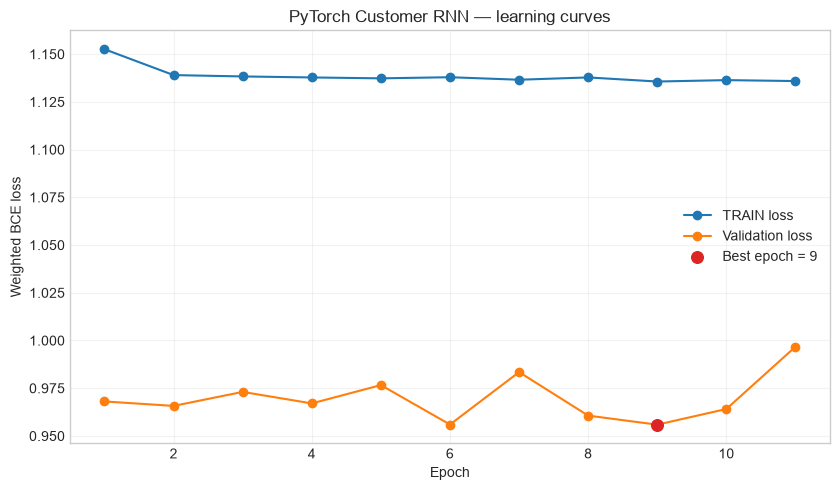

Đã lưu: C:\DATA\assign\A06\results\figures\pytorch_customer\training_validation_loss.png


In [ ]:
history = training_result["history"]
epochs = np.arange(1, training_result["epochs_ran"] + 1)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(epochs, history["train_loss"], marker="o", label="TRAIN loss")
ax.plot(epochs, history["validation_loss"], marker="o", label="Validation loss")
best_epoch = training_result["best_epoch"]
ax.scatter(
    best_epoch,
    history["validation_loss"][best_epoch - 1],
    color="#DC2626",
    s=70,
    zorder=3,
    label=f"Best epoch = {best_epoch}",
)
ax.set(
    title="PyTorch Customer RNN — learning curves",
    xlabel="Epoch",
    ylabel="Weighted BCE loss",
)
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
loss_figure_path = FIGURE_DIR / "training_validation_loss.png"
fig.savefig(loss_figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("Đã lưu:", loss_figure_path)

## 8. Đánh giá TEST đúng một lần

Model hiện tại đã là best validation-state. Cell dưới đây thực hiện lần inference duy nhất trên TEST, chuyển logits thành xác suất bằng Sigmoid **ở ngoài model**, và dùng threshold cố định 0.5. Threshold không được tinh chỉnh bằng TEST.

Các metric:

- **Accuracy:** tỷ lệ dự đoán đúng, nhưng dễ gây hiểu nhầm khi class 0 chiếm đa số.
- **Precision:** trong các dự đoán “sẽ mua”, bao nhiêu trường hợp thực sự mua.
- **Recall:** trong các trường hợp thực sự mua, model tìm được bao nhiêu.
- **F1:** harmonic mean của precision và recall.
- **ROC-AUC:** khả năng xếp positive sample cao hơn negative sample trên mọi threshold.


In [8]:
test_labels, test_probabilities = predict_probabilities(
    model,
    loaders["test"],
    device=DEVICE,
)
THRESHOLD = 0.5
test_predictions = (test_probabilities >= THRESHOLD).astype(np.int8)
test_metrics = binary_classification_metrics(
    test_labels,
    test_probabilities,
    threshold=THRESHOLD,
)
test_confusion = confusion_matrix(test_labels, test_predictions, labels=[0, 1])

metrics_table = pd.DataFrame(
    {"metric": list(test_metrics), "value": list(test_metrics.values())}
).set_index("metric")
display(metrics_table.style.format("{:.4f}"))
display(
    pd.DataFrame(
        test_confusion,
        index=["True 0", "True 1"],
        columns=["Pred 0", "Pred 1"],
    )
)

predictions = pd.DataFrame(
    {
        "CustomerID": splits["test"]["customer_id"].astype(np.int64),
        "target_week": np.datetime_as_string(splits["test"]["target_week"], unit="D"),
        "true_label": test_labels.astype(np.int8),
        "probability": test_probabilities.astype(np.float64),
        "predicted_label": test_predictions,
    }
)
assert len(predictions) == len(splits["test"]["y"])
assert np.array_equal(predictions["true_label"].to_numpy(), splits["test"]["y"])
predictions.to_csv(PREDICTIONS_PATH, index=False, float_format="%.8f")

print(f"Đã lưu {len(predictions):,} TEST predictions: {PREDICTIONS_PATH}")
display(predictions.head())

,value
metric,
accuracy,0.7582
precision,0.1587
recall,0.5722
f1,0.2485
roc_auc,0.7009


,Pred 0,Pred 1
True 0,38101,11244
True 1,1586,2121


Đã lưu 53,052 TEST predictions: C:\DATA\assign\A06\results\predictions\pytorch_customer_predictions.csv


,CustomerID,target_week,true_label,probability,predicted_label
0,12346,2011-09-26,0,0.306614,0
1,12347,2011-09-26,0,0.575509,1
2,12348,2011-09-26,0,0.294810,0
3,12349,2011-09-26,0,0.306614,0
4,12350,2011-09-26,0,0.306614,0


## 9. Confusion matrix

Confusion matrix cho biết trực tiếp số true negatives, false positives, false negatives và true positives. Với dữ liệu lệch lớp, đây là bổ sung quan trọng cho accuracy: model có thể tăng recall bằng cách chấp nhận nhiều false positives hơn.


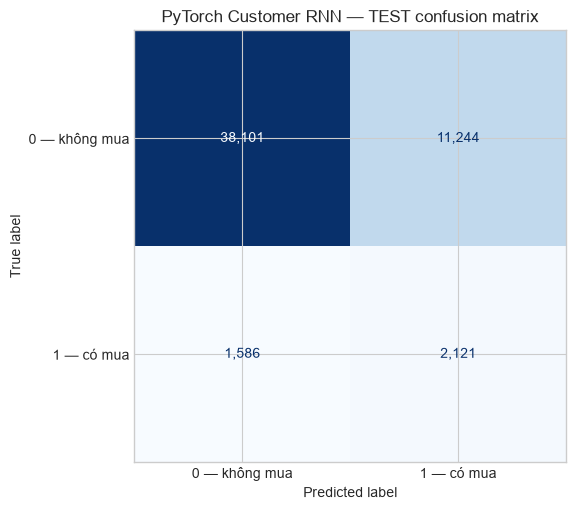

Đã lưu: C:\DATA\assign\A06\results\figures\pytorch_customer\test_confusion_matrix.png


In [9]:
fig, ax = plt.subplots(figsize=(6.2, 5.2))
display_cm = ConfusionMatrixDisplay(
    confusion_matrix=test_confusion,
    display_labels=["0 — không mua", "1 — có mua"],
)
display_cm.plot(ax=ax, cmap="Blues", colorbar=False, values_format=",d")
ax.set_title("PyTorch Customer RNN — TEST confusion matrix")
fig.tight_layout()
confusion_figure_path = FIGURE_DIR / "test_confusion_matrix.png"
fig.savefig(confusion_figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("Đã lưu:", confusion_figure_path)

## 10. ROC curve

ROC curve quét qua nhiều thresholds và so sánh true-positive rate với false-positive rate. Đường chéo là ranking ngẫu nhiên; ROC-AUC càng gần 1 thì khả năng phân hạng càng tốt. ROC-AUC không thay thế precision/recall tại threshold 0.5, đặc biệt khi positive class hiếm.


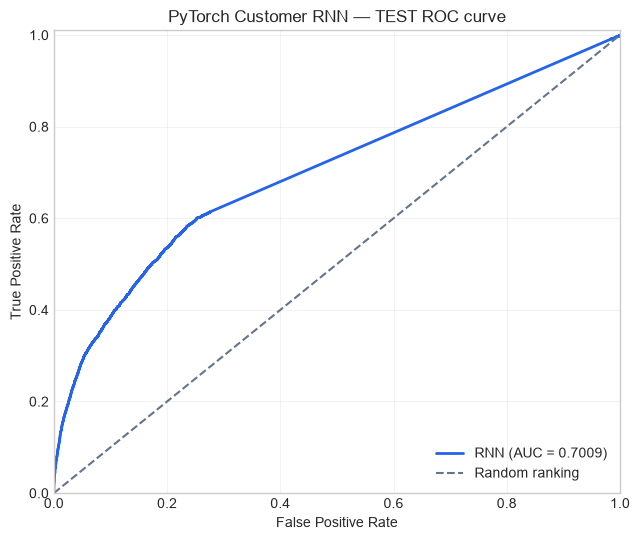

Đã lưu: C:\DATA\assign\A06\results\figures\pytorch_customer\test_roc_curve.png


In [10]:
false_positive_rate, true_positive_rate, _ = roc_curve(test_labels, test_probabilities)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(
    false_positive_rate,
    true_positive_rate,
    color="#2563EB",
    linewidth=2,
    label=f"RNN (AUC = {test_metrics['roc_auc']:.4f})",
)
ax.plot([0, 1], [0, 1], linestyle="--", color="#64748B", label="Random ranking")
ax.set(
    title="PyTorch Customer RNN — TEST ROC curve",
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    xlim=(0, 1),
    ylim=(0, 1.01),
)
ax.legend(loc="lower right")
ax.grid(alpha=0.25)
fig.tight_layout()
roc_figure_path = FIGURE_DIR / "test_roc_curve.png"
fig.savefig(roc_figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("Đã lưu:", roc_figure_path)

## 11. Lưu metrics và provenance

JSON kết quả ghi lại architecture, training protocol, class weighting, duration, TEST metrics và checksum của các input/output artifacts. Điều này cho phép Notebook 08 so sánh framework trên đúng cùng samples mà không phải suy đoán lại cấu hình.


In [ ]:
checkpoint_hash = sha256_file(CHECKPOINT_PATH)
predictions_hash = sha256_file(PREDICTIONS_PATH)

metrics_payload = {
    "experiment": "PyTorch Customer Vanilla RNN",
    "seed": SEED,
    "device": str(DEVICE),
    "architecture": {
        "recurrent_layer": "torch.nn.RNN",
        "input_size": INPUT_SIZE,
        "sequence_length": 8,
        "hidden_size": HIDDEN_SIZE,
        "num_layers": NUM_LAYERS,
        "batch_first": True,
        "nonlinearity": "tanh",
        "head": "Linear(64, 1) producing one logit",
        "sigmoid_inside_model": False,
        "parameter_count": parameter_count,
    },
    "data": {
        "feature_names": feature_names,
        "split_shapes": {name: list(data["X"].shape) for name, data in splits.items()},
        "source_artifacts": customer_metadata["artifacts"],
    },
    "training": {
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "criterion": "BCEWithLogitsLoss",
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,
        "gradient_clip_norm": GRADIENT_CLIP_NORM,
        "epochs_actually_run": training_result["epochs_ran"],
        "best_epoch": training_result["best_epoch"],
        "best_validation_loss": training_result["best_validation_loss"],
        "training_duration_seconds": training_result["training_duration_seconds"],
        "selection_scope": "validation loss only; TEST unused until final evaluation",
        "history": history,
    },
    "class_weighting": {
        "used": True,
        "type": "positive class weight in BCEWithLogitsLoss",
        "positive_weight": positive_weight,
        "formula": "TRAIN negatives / TRAIN positives",
        "fit_scope": "TRAIN y only",
        "train_class_0": int(np.count_nonzero(splits["train"]["y"] == 0)),
        "train_class_1": int(np.count_nonzero(splits["train"]["y"] == 1)),
    },
    "evaluation": {
        "split": "TEST",
        "evaluations_on_test": 1,
        "threshold": THRESHOLD,
        "metrics": test_metrics,
        "confusion_matrix_tn_fp_fn_tp": {
            "tn": int(test_confusion[0, 0]),
            "fp": int(test_confusion[0, 1]),
            "fn": int(test_confusion[1, 0]),
            "tp": int(test_confusion[1, 1]),
        },
    },
    "artifacts": {
        "checkpoint": {
            "path": CHECKPOINT_PATH.relative_to(PROJECT_ROOT).as_posix(),
            "sha256": checkpoint_hash,
        },
        "predictions": {
            "path": PREDICTIONS_PATH.relative_to(PROJECT_ROOT).as_posix(),
            "rows": len(predictions),
            "sha256": predictions_hash,
        },
        "figures": [
            loss_figure_path.relative_to(PROJECT_ROOT).as_posix(),
            confusion_figure_path.relative_to(PROJECT_ROOT).as_posix(),
            roc_figure_path.relative_to(PROJECT_ROOT).as_posix(),
        ],
    },
}
METRICS_PATH.write_text(
    json.dumps(metrics_payload, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)

print("Metrics JSON:", METRICS_PATH)
print("Checkpoint SHA-256:", checkpoint_hash)
print("Predictions SHA-256:", predictions_hash)

Metrics JSON: C:\DATA\assign\A06\results\metrics\pytorch_customer_metrics.json
Checkpoint SHA-256: 6eac526856bbd7c669b45668df01712b94551cbd15f83808823dce7947a43eab
Predictions SHA-256: 39ef1e482e1d260e77c75ed2fab64b8e2099d7389498601651b604ee65275f0e
